# Phase 2: Preprocessing

Clean and prepare the combined HMS dataset for analysis.

**Steps:**
1. Load combined data
2. Audit missing values
3. Convert data types
4. Encode categorical variables
5. Compute derived features
6. Save clean dataset


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams['figure.dpi'] = 110

df23 = pd.read_csv('HMS_2023-2024_PUBLIC_instchars.csv', low_memory=False)
df24 = pd.read_csv('HMS_2024-2025_PUBLIC_instchars.csv', low_memory=False)

DEMO_COLS = ['age','sex_birth','gender_male','gender_female','gender_queer','gender_nonbin',
             'race_black','race_white','race_asian','race_his','race_ainaan',
             'international','pellgrant','housing_worry','degree_bach','degree_ma','degree_phd',
             'yr_sch','enroll']
INST_COLS  = ['inst_type','inst_public','inst_size','inst_geo']
PHQ9_ITEMS = [f'phq9_{i}' for i in range(1,10)]
GAD7_ITEMS = [f'gad7_{i}' for i in range(1,8)]
DIENER_ITEMS = [f'diener{i}' for i in range(1,9)]
LONELY_ITEMS = ['lone_lackcompanion','lone_leftout','lone_isolated']
OUTCOME_COLS = ['dep_any','dep_maj','anx_any','anx_sev','sui_idea','sui_plan','sui_att',
                'deprawsc','anx_score','flourish','lonely','sib_any','sub_any','ed_any']
TREATMENT_COLS = ['ther_any','meds_any','percneed','percneed_cur']
STRESS_COLS = ['housing_worry','food_worry','FinStress']
ALL_COLS = list(set(DEMO_COLS+INST_COLS+PHQ9_ITEMS+GAD7_ITEMS+DIENER_ITEMS+
                    LONELY_ITEMS+OUTCOME_COLS+TREATMENT_COLS+STRESS_COLS))
common = list(set(df23.columns) & set(df24.columns))
keep = [c for c in ALL_COLS if c in common]

df23_sel = df23[keep].copy(); df23_sel['year'] = '2023-2024'
df24_sel = df24[keep].copy(); df24_sel['year'] = '2024-2025'
df = pd.concat([df23_sel, df24_sel], ignore_index=True)
print(f"Combined: {df.shape[0]:,} rows x {df.shape[1]} columns")

Combined: 189,464 rows x 71 columns


## 2.1 Missing Value Audit

Columns with missing values: 65 / 71
Total missing cells: 2,764,579 (20.6% of all cells)



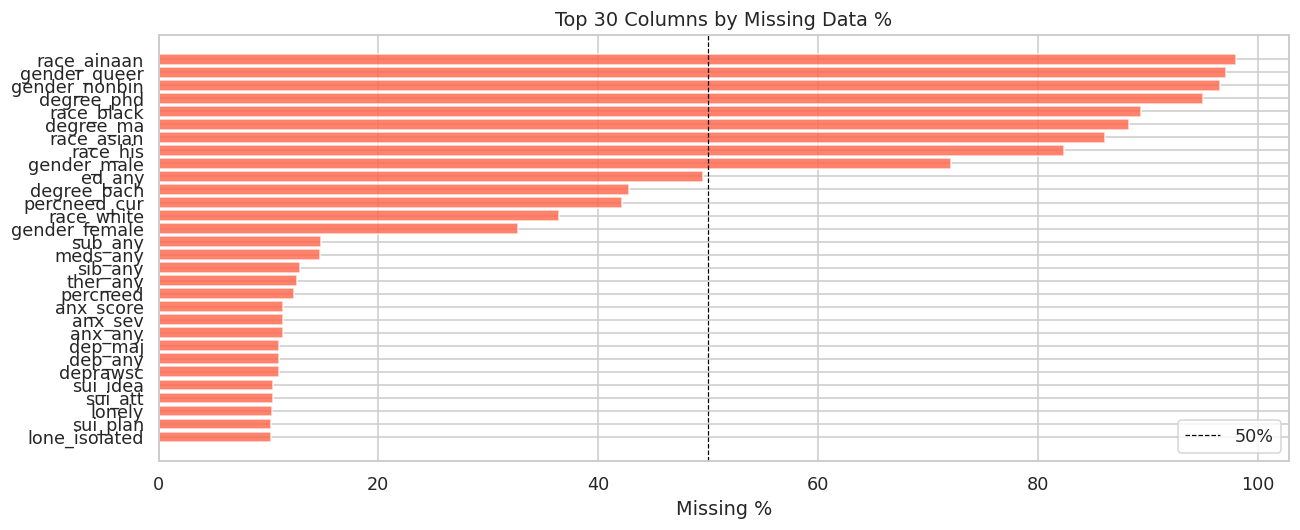

In [2]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
miss_df = pd.DataFrame({'missing_n': missing, 'missing_pct': missing_pct})
miss_df = miss_df[miss_df['missing_n'] > 0].sort_values('missing_pct', ascending=False)

print(f"Columns with missing values: {len(miss_df)} / {df.shape[1]}")
print(f"Total missing cells: {missing.sum():,} ({missing.sum()/(df.shape[0]*df.shape[1])*100:.1f}% of all cells)")
print()

fig, ax = plt.subplots(figsize=(12, 5))
top_miss = miss_df.head(30)
ax.barh(top_miss.index[::-1], top_miss['missing_pct'][::-1], color='tomato', alpha=0.8)
ax.set_xlabel('Missing %')
ax.set_title('Top 30 Columns by Missing Data %')
ax.axvline(50, color='black', linestyle='--', linewidth=0.8, label='50%')
ax.legend()
plt.tight_layout(); plt.show()

## 2.2 Convert Types & Encode Labels

In [3]:
# Force numeric on all item/score columns
num_cols = PHQ9_ITEMS + GAD7_ITEMS + DIENER_ITEMS + LONELY_ITEMS + OUTCOME_COLS + TREATMENT_COLS
for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df['age'] = pd.to_numeric(df['age'], errors='coerce')

# Gender label (mutually exclusive priority)
def gender_label(row):
    if row.get('gender_nonbin') == 1: return 'Non-binary'
    if row.get('gender_queer')  == 1: return 'Genderqueer'
    if row.get('gender_female') == 1: return 'Woman'
    if row.get('gender_male')   == 1: return 'Man'
    return 'Other/Unknown'
df['gender'] = df.apply(gender_label, axis=1)

# Race label (first match, simplified)
def race_label(row):
    if row.get('race_black') == 1:  return 'Black'
    if row.get('race_asian') == 1:  return 'Asian'
    if row.get('race_his')   == 1:  return 'Hispanic'
    if row.get('race_ainaan')== 1:  return 'Indigenous'
    if row.get('race_white') == 1:  return 'White'
    return 'Other/Multiracial'
df['race'] = df.apply(race_label, axis=1)

# Year in school label
yr_map = {1:'1st Year',2:'2nd Year',3:'3rd Year',4:'4th Year',5:'5th+ Year'}
df['year_school'] = pd.to_numeric(df['yr_sch'], errors='coerce').map(yr_map)

# Institution type label
inst_type_map = {1:'2-Year',2:'4-Year Private',3:'4-Year Public',4:'Graduate',5:'Other'}
df['inst_type_label'] = pd.to_numeric(df['inst_type'], errors='coerce').map(inst_type_map)

# Institution size label
inst_size_map = {1:'<1k',2:'1-5k',3:'5-10k',4:'10-20k',5:'>20k'}
df['inst_size_label'] = pd.to_numeric(df['inst_size'], errors='coerce').map(inst_size_map)

# Low income flag
df['low_income'] = pd.to_numeric(df['pellgrant'], errors='coerce').eq(1).astype(float)

# Housing insecurity flag
df['housing_insecure'] = pd.to_numeric(df['housing_worry'], errors='coerce').ge(2).astype(float)

print("Encoding complete.")
print(df[['gender','race','year_school','inst_type_label','inst_size_label']].value_counts('gender').head())

Encoding complete.
gender
Woman            124776
Man               51720
Non-binary         6357
Genderqueer        3561
Other/Unknown      3050
Name: count, dtype: int64


## 2.3 Compute Derived Scores

In [4]:
# PHQ-9 total (items already 0-3 each, sum = 0-27)
phq_present = [c for c in PHQ9_ITEMS if c in df.columns]
df['phq9_total'] = df[phq_present].sum(axis=1, min_count=len(phq_present)//2)

# GAD-7 total (0-21)
gad_present = [c for c in GAD7_ITEMS if c in df.columns]
df['gad7_total'] = df[gad_present].sum(axis=1, min_count=len(gad_present)//2)

# Diener Flourishing (8-56)
diener_present = [c for c in DIENER_ITEMS if c in df.columns]
df['flourishing'] = df[diener_present].sum(axis=1, min_count=len(diener_present)//2)

# UCLA Loneliness (3-9)
lonely_present = [c for c in LONELY_ITEMS if c in df.columns]
df['loneliness'] = df[lonely_present].sum(axis=1, min_count=2)

# Composite mental health burden (0-1, higher = worse)
df['mh_burden'] = (
    df['phq9_total'].fillna(0)/27 * 0.4 +
    df['gad7_total'].fillna(0)/21 * 0.4 +
    (df['loneliness'].fillna(6)-3)/6 * 0.2
)

print("Derived scores:")
for col in ['phq9_total','gad7_total','flourishing','loneliness','mh_burden']:
    if col in df.columns:
        print(f"  {col:15s}: mean={df[col].mean():.2f}  std={df[col].std():.2f}  missing={df[col].isna().sum():,}")

Derived scores:
  phq9_total     : mean=17.47  std=6.25  missing=16,376
  gad7_total     : mean=14.63  std=5.82  missing=17,864
  flourishing    : mean=43.33  std=9.09  missing=14,633
  loneliness     : mean=5.59  std=1.96  missing=19,099
  mh_burden      : mean=0.58  std=0.27  missing=0


## 2.4 Final Dataset Overview

In [5]:
print(f"Final shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print()
print("Year breakdown:")
print(df['year'].value_counts().to_string())
print()
print("Gender breakdown:")
print(df['gender'].value_counts().to_string())
print()
print("Race breakdown:")
print(df['race'].value_counts().to_string())
print()
print("Score summary:")
df[['phq9_total','gad7_total','flourishing','loneliness','mh_burden']].describe().round(2)

Final shape: 189,464 rows x 83 columns

Year breakdown:
year
2023-2024    104729
2024-2025     84735

Gender breakdown:
gender
Woman            124776
Man               51720
Non-binary         6357
Genderqueer        3561
Other/Unknown      3050

Race breakdown:
race
White                104091
Hispanic              30896
Asian                 25766
Black                 20133
Other/Multiracial      6364
Indigenous             2214

Score summary:


,phq9_total,gad7_total,flourishing,loneliness,mh_burden
count,173088.00,171600.00,174831.00,170365.00,189464.00
mean,17.47,14.63,43.33,5.59,0.58
std,6.25,5.82,9.09,1.96,0.27
min,4.00,3.00,4.00,2.00,-0.03
25%,13.00,10.00,39.00,4.00,0.39
50%,16.00,14.00,45.00,6.00,0.56
75%,21.00,19.00,49.00,7.00,0.76
max,36.00,28.00,56.00,9.00,1.27


## 2.5 Save Clean Dataset

In [6]:
df.to_csv('HMS_clean.csv', index=False)
print(f"Saved HMS_clean.csv  ({df.shape[0]:,} rows x {df.shape[1]} columns)")

Saved HMS_clean.csv  (189,464 rows x 83 columns)


---
## 2.6 Post-Preprocessing Analytics

A comprehensive look at the clean dataset before any analysis begins.

### Score Distributions & Normality

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv('HMS_clean.csv', low_memory=False)
for col in ['phq9_total','gad7_total','flourishing','loneliness','mh_burden']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

score_configs = [
    ('phq9_total',  'PHQ-9 (Depression)',    'steelblue',   27),
    ('gad7_total',  'GAD-7 (Anxiety)',        'darkorange',  21),
    ('flourishing', 'Flourishing (Diener)',   'mediumseagreen', 56),
    ('loneliness',  'Loneliness (UCLA)',      'mediumpurple', 9),
    ('mh_burden',   'MH Burden (composite)', 'tomato',       1),
]

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
ax_flat = axes.ravel()

for ax, (col, label, color, max_val) in zip(ax_flat, score_configs):
    data = df[col].dropna()
    sns.histplot(data, bins=40, kde=True, ax=ax, color=color, alpha=0.75)
    ax.axvline(data.mean(),   color='red',   linestyle='--', lw=1.5, label=f'Mean={data.mean():.1f}')
    ax.axvline(data.median(), color='black', linestyle=':',  lw=1.5, label=f'Median={data.median():.1f}')
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('Score')
    ax.legend(fontsize=8)
    # Skewness annotation
    skew = data.skew()
    ax.text(0.97, 0.95, f'skew={skew:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=8, color='gray')

ax_flat[-1].set_visible(False)
plt.suptitle('Clinical Score Distributions After Preprocessing', fontsize=13)
plt.tight_layout(); plt.show()

print("Score summary statistics:")
print(df[['phq9_total','gad7_total','flourishing','loneliness','mh_burden']].describe().round(2))


### Missing Data Heatmap

In [ ]:
# Missing data pattern across key columns
key_cols = ['phq9_total','gad7_total','flourishing','loneliness','mh_burden',
            'low_income','housing_insecure','sui_idea','sui_plan','sui_att',
            'sib_any','sub_any','ther_any','meds_any','percneed_cur']

miss_pct = df[key_cols].isnull().mean() * 100
miss_df  = miss_pct.reset_index()
miss_df.columns = ['Column','Missing %']
miss_df = miss_df.sort_values('Missing %', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['tomato' if p > 20 else 'darkorange' if p > 10 else 'steelblue'
          for p in miss_df['Missing %']]
bars = ax.barh(miss_df['Column'], miss_df['Missing %'], color=colors, edgecolor='white')
ax.set_xlabel('Missing %')
ax.set_title('Missing Data by Column (Key Variables)')
ax.axvline(10, color='gray', linestyle='--', lw=0.8, label='10% threshold')
ax.axvline(20, color='gray', linestyle=':',  lw=0.8, label='20% threshold')
ax.legend(fontsize=9)
for bar, pct in zip(bars, miss_df['Missing %']):
    ax.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=8)
plt.tight_layout(); plt.show()


### Demographic Breakdown

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

# Gender
g = df['gender'].value_counts()
axes[0,0].pie(g, labels=g.index, autopct='%1.1f%%',
              colors=sns.color_palette('Set2', len(g)), startangle=140,
              wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[0,0].set_title('Gender Identity')

# Race
r = df['race'].value_counts()
axes[0,1].barh(r.index[::-1], r.values[::-1], color=sns.color_palette('tab10', len(r)))
axes[0,1].set_title('Race/Ethnicity')
axes[0,1].set_xlabel('Count')
for i, v in enumerate(r.values[::-1]):
    axes[0,1].text(v+200, i, f'{v:,}', va='center', fontsize=8)

# Year in school
YEAR_ORD = ['1st Year','2nd Year','3rd Year','4th Year','5th+ Year']
yr = df['year_school'].value_counts().reindex(YEAR_ORD).fillna(0)
axes[0,2].bar(YEAR_ORD, yr, color=sns.color_palette('Blues_d', 5))
axes[0,2].set_title('Year in School')
axes[0,2].set_ylabel('Count')
axes[0,2].tick_params(axis='x', rotation=20)
for p, v in zip(axes[0,2].patches, yr):
    axes[0,2].annotate(f'{int(v):,}', (p.get_x()+p.get_width()/2, p.get_height()),
                       ha='center', va='bottom', fontsize=8)

# Institution type
it = df['inst_type_label'].value_counts()
axes[1,0].pie(it, labels=it.index, autopct='%1.1f%%',
              colors=sns.color_palette('Pastel1', len(it)), startangle=90,
              wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1,0].set_title('Institution Type')

# Institution size
INST_SIZE_ORD = ['<1k','1-5k','5-10k','10-20k','>20k']
is_ = df['inst_size_label'].value_counts().reindex(INST_SIZE_ORD).fillna(0)
axes[1,1].bar(INST_SIZE_ORD, is_, color=sns.color_palette('Greens_d', 5))
axes[1,1].set_title('Institution Size')
axes[1,1].set_ylabel('Count')

# Survey year
sy = df['year'].value_counts()
axes[1,2].pie(sy, labels=sy.index, autopct='%1.1f%%',
              colors=['steelblue','darkorange'], startangle=90,
              wedgeprops={'edgecolor':'white','linewidth':2})
axes[1,2].set_title('Survey Year')

plt.suptitle('Demographic Overview — Clean Dataset (N={:,})'.format(len(df)), fontsize=13, y=1.01)
plt.tight_layout(); plt.show()


### Binary Variable Prevalence

In [ ]:
binary_vars = {
    'low_income':       'Low Income (Pell Grant)',
    'housing_insecure': 'Housing Insecurity',
    'food_worry':       'Food Insecurity',
    'sub_any':          'Any Substance Use',
    'sib_any':          'Self-Injury',
    'ther_any':         'Currently in Therapy',
    'meds_any':         'On Psychiatric Medication',
    'percneed_cur':     'Unmet Mental Health Need',
    'sui_idea':         'Suicidal Ideation',
    'sui_plan':         'Suicide Plan',
    'sui_att':          'Suicide Attempt',
}

for col in binary_vars:
    df[col] = pd.to_numeric(df[col], errors='coerce')

rates = {label: df[col].eq(1).mean()*100
         for col, label in binary_vars.items()}
rates_s = dict(sorted(rates.items(), key=lambda x: x[1], reverse=True))

fig, ax = plt.subplots(figsize=(11, 7))
colors = ['tomato' if v > 20 else 'darkorange' if v > 10 else 'steelblue'
          for v in rates_s.values()]
bars = ax.barh(list(rates_s.keys()), list(rates_s.values()),
               color=colors, edgecolor='white', height=0.65)
ax.set_xlabel('Prevalence (%)')
ax.set_title('Binary Variable Prevalence in Clean Dataset')
ax.set_xlim(0, 45)
for bar, val in zip(bars, rates_s.values()):
    ax.text(bar.get_width()+0.4, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontweight='bold', fontsize=9)
plt.tight_layout(); plt.show()


### Score Correlation Matrix

In [ ]:
score_cols = ['phq9_total','gad7_total','flourishing','loneliness','mh_burden']
score_labels = ['PHQ-9\n(Depression)','GAD-7\n(Anxiety)',
                'Flourishing','Loneliness','MH Burden']

corr = df[score_cols].corr()
corr.index   = score_labels
corr.columns = score_labels

fig, ax = plt.subplots(figsize=(8, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax,
            annot_kws={'size':11}, cbar_kws={'shrink':0.8})
ax.set_title('Score Correlation Matrix\n(lower triangle)', fontsize=12)
plt.tight_layout(); plt.show()

print("Key correlations:")
pairs = [('phq9_total','gad7_total'),('phq9_total','loneliness'),
         ('phq9_total','flourishing'),('gad7_total','loneliness'),
         ('flourishing','loneliness')]
for a, b in pairs:
    r = df[[a,b]].corr().iloc[0,1]
    print(f"  {a:15s} ↔ {b:15s}: r = {r:.3f}")


### Score Distributions by Survey Year

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(17, 5))
score_plot = [
    ('phq9_total',  'PHQ-9 (Depression)',  'steelblue'),
    ('gad7_total',  'GAD-7 (Anxiety)',     'darkorange'),
    ('flourishing', 'Flourishing',         'mediumseagreen'),
    ('loneliness',  'Loneliness',          'mediumpurple'),
]
for ax, (col, label, color) in zip(axes, score_plot):
    for yr, ls in [('2023-2024','--'),('2024-2025','-')]:
        data = df[df['year']==yr][col].dropna()
        sns.kdeplot(data, ax=ax, label=yr, linestyle=ls, linewidth=2)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('Score')
    ax.legend(fontsize=8)

plt.suptitle('Score Distributions: 2023-2024 vs 2024-2025', fontsize=13)
plt.tight_layout(); plt.show()

print("Mean scores by year:")
print(df.groupby('year')[['phq9_total','gad7_total','flourishing','loneliness']].mean().round(2))


### Financial Stress Profile

In [ ]:
df['fin_stress_score'] = (
    df['low_income'].eq(1).astype(float) +
    df['housing_insecure'].eq(1).astype(float) +
    df['food_worry'].ge(2).astype(float)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of financial stress score
fs_counts = df['fin_stress_score'].value_counts().sort_index()
labels_fs = ['None (0)','1 stressor','2 stressors','3 stressors']
colors_fs = ['mediumseagreen','gold','darkorange','tomato']
bars = axes[0].bar(labels_fs[:len(fs_counts)], fs_counts.values,
                   color=colors_fs[:len(fs_counts)], edgecolor='white')
axes[0].set_title('Financial Stress Score Distribution\n(0=none, 3=all three stressors)')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, fs_counts.values):
    pct = val/len(df)*100
    axes[0].annotate(f'{val:,}\n({pct:.1f}%)',
                     (bar.get_x()+bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom', fontsize=9)

# Mean PHQ-9 by financial stress score
mean_phq = df.groupby('fin_stress_score')['phq9_total'].mean().reindex([0,1,2,3])
axes[1].bar(labels_fs[:len(mean_phq)], mean_phq.values,
            color=colors_fs[:len(mean_phq)], edgecolor='white')
axes[1].set_title('Mean PHQ-9 Score by Financial Stress Level')
axes[1].set_ylabel('Mean PHQ-9 Score (0-27)')
for i, val in enumerate(mean_phq.values):
    if not np.isnan(val):
        axes[1].annotate(f'{val:.1f}', (i, val),
                         ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.suptitle('Financial Stress Profile', fontsize=13)
plt.tight_layout(); plt.show()


### Dataset Summary Table

In [ ]:
print("CLEAN DATASET SUMMARY")
print("=" * 55)
print(f"Total students       : {len(df):,}")
print(f"Survey years         : {sorted(df['year'].unique())}")
print(f"Columns              : {df.shape[1]}")
print()
print("Clinical Scores (mean ± std):")
for col, label, max_val in [
    ('phq9_total',  'PHQ-9 Depression (0-27)',  27),
    ('gad7_total',  'GAD-7 Anxiety   (0-21)',   21),
    ('flourishing', 'Flourishing     (8-56)',   56),
    ('loneliness',  'Loneliness      (3-9)',     9),
]:
    m = df[col].mean(); s = df[col].std()
    pct = m/max_val*100
    print(f"  {label}: {m:.1f} ± {s:.1f}  ({pct:.0f}% of max)")
print()
print("Key Prevalence Rates:")
for col, label in [
    ('sui_idea','Suicidal ideation'),
    ('sib_any', 'Self-injury'),
    ('ther_any','In therapy'),
    ('meds_any','On medication'),
    ('low_income','Low income (Pell)'),
    ('housing_insecure','Housing insecure'),
]:
    pct = df[col].eq(1).mean()*100
    print(f"  {label:25s}: {pct:.1f}%")
